# Nowcasting de inundações urbanas com modelos U-RNN simplificados

Este notebook implementa uma solução demonstrativa para nowcasting de inundações urbanas, inspirada no modelo U-RNN. A proposta original usa séries espaço-temporais de chuva, mapas estáticos urbanos e redes recorrentes convolucionais para prever profundidade de inundação em alta resolução.

Como o arquivo `urbanflood24.zip` é grande e o treinamento completo exige mais armazenamento e GPU, esta versão foi adaptada para execução local em CPU. O repositório inclui um subconjunto já processado em `data_demo/processed/`, e o notebook também consegue regenerar esse subconjunto a partir do ZIP original quando ele estiver disponível.

**Materiais de referência obrigatórios:**

- Artigo: U-RNN: High-resolution Spatiotemporal Nowcasting of Urban Flooding, Journal of Hydrology, 2025.
- Dataset: Supplementary data of U-RNN high-resolution spatiotemporal nowcasting of urban flooding.
- GitHub oficial: https://github.com/holmescao/U-RNN

## Decisões técnicas desta implementação

- O dataset completo não é descompactado. Para reprodutibilidade no GitHub, a entrega inclui apenas o subconjunto leve em `data_demo/processed/`.
- Se `urbanflood24.zip` estiver disponível, o notebook também consegue recriar os arquivos processados lendo apenas os eventos necessários dentro do ZIP.
- A grade original de `500 x 500` e `360` passos de 1 minuto é reduzida para uma grade de `128 x 128` e `36` passos de 10 minutos, seguindo a ideia do UrbanFlood24 Lite descrita pelos autores.
- O modelo implementado é um **Mini U-RNN**: uma versão compacta com encoder convolucional, célula ConvGRU e decoder convolucional.
- A entrega inclui um baseline de persistência, métricas e mapas comparativos.

Esta versão é uma reprodução simplificada e verificável do fluxo computacional, não uma reprodução integral dos resultados do artigo.

In [1]:
from pathlib import Path
import io
import json
import math
import time
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

ZIP_PATH = Path("urbanflood24.zip")
DATA_DIR = Path("data_demo/processed")
OUTPUT_DIR = Path("outputs")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOCATION = "location1"
TRAIN_EVENTS = [
    "G1135_intensity_117",
    "G1135_intensity_155",
    "G1135_intensity_156",
    "G1135_intensity_163",
    "G1162_intensity_170",
    "G1166_intensity_120",
    "G3501_intensity_105",
    "G3555_intensity_284",
]
TEST_EVENTS = [
    "G1135_intensity_103",
    "G1135_intensity_161",
    "G1166_intensity_246",
    "G3501_intensity_151",
]
TEST_EVENT_FOR_FIGURES = TEST_EVENTS[0]

TEMPORAL_STEPS = 36
CENTER_CROP = 384
SPATIAL_SIZE = 128
DEVICE = torch.device("cpu")

print("Python pronto.")
print(f"PyTorch: {torch.__version__}")
print(f"Dispositivo usado: {DEVICE}")

Python pronto.
PyTorch: 2.7.1+cpu
Dispositivo usado: cpu


## 1. Inspeção dos dados disponíveis

A primeira etapa verifica se o subconjunto processado já está disponível no repositório. Se estiver, o notebook usa esses arquivos diretamente. Se não estiver, ele tenta localizar `urbanflood24.zip` para gerar o subconjunto sem descompactar o dataset inteiro.

In [2]:
def expected_processed_paths() -> tuple[Path, list[Path], list[Path]]:
    geodata = DATA_DIR / f"geodata_{LOCATION}.npz"
    train = [DATA_DIR / f"train_{LOCATION}_{event}.npz" for event in TRAIN_EVENTS]
    test = [DATA_DIR / f"test_{LOCATION}_{event}.npz" for event in TEST_EVENTS]
    return geodata, train, test


expected_geodata_path, expected_train_paths, expected_test_paths = expected_processed_paths()
expected_paths = [expected_geodata_path, *expected_train_paths, *expected_test_paths]
missing_processed = [path for path in expected_paths if not path.exists()]
USE_PREPROCESSED = len(missing_processed) == 0

if USE_PREPROCESSED:
    total_processed_mb = sum(path.stat().st_size for path in expected_paths) / 1e6
    print("Subconjunto processado encontrado em data_demo/processed/.")
    print(f"Tamanho do subconjunto usado pelo notebook: {total_processed_mb:.2f} MB")
else:
    print("Subconjunto processado incompleto. Arquivos ausentes:")
    for path in missing_processed[:5]:
        print(" -", path)

    if not ZIP_PATH.exists():
        raise FileNotFoundError(
            "Não encontrei todos os arquivos em data_demo/processed/ e o arquivo urbanflood24.zip "
            "também não está na raiz. Use os dados processados do repositório ou coloque o ZIP original aqui."
        )

    with zipfile.ZipFile(ZIP_PATH) as zf:
        infos = [info for info in zf.infolist() if not info.is_dir()]
        total_compactado = sum(info.compress_size for info in infos) / 1e9
        total_descompactado = sum(info.file_size for info in infos) / 1e9
        names = {info.filename for info in infos}

        required = []
        for event in TRAIN_EVENTS:
            base = f"urbanflood24/train/flood/{LOCATION}/{event}"
            required.extend([f"{base}/flood.npy", f"{base}/rainfall.npy"])
        for event in TEST_EVENTS:
            base = f"urbanflood24/test/flood/{LOCATION}/{event}"
            required.extend([f"{base}/flood.npy", f"{base}/rainfall.npy"])
        for static_name in ["absolute_DSM.npy", "impervious.npy", "manhole.npy"]:
            required.append(f"urbanflood24/train/geodata/{LOCATION}/{static_name}")

        missing = [name for name in required if name not in names]
        if missing:
            raise FileNotFoundError("Arquivos esperados não encontrados no ZIP: " + str(missing[:5]))

    print(f"Arquivos no ZIP: {len(infos)}")
    print(f"Tamanho compactado aproximado: {total_compactado:.2f} GB")
    print(f"Tamanho descompactado aproximado: {total_descompactado:.2f} GB")
print("Eventos de treino:", TRAIN_EVENTS)
print("Eventos de teste:", TEST_EVENTS)

Subconjunto processado encontrado em data_demo/processed/.
Tamanho do subconjunto usado pelo notebook: 6.74 MB
Eventos de treino: ['G1135_intensity_117', 'G1135_intensity_155', 'G1135_intensity_156', 'G1135_intensity_163', 'G1162_intensity_170', 'G1166_intensity_120', 'G3501_intensity_105', 'G3555_intensity_284']
Eventos de teste: ['G1135_intensity_103', 'G1135_intensity_161', 'G1166_intensity_246', 'G3501_intensity_151']


## 2. Redução espaço-temporal dos dados

Cada arquivo `flood.npy` original tem formato `(360, 1, 500, 500)`. A redução aplicada aqui cria uma versão leve:

- média temporal por blocos de 10 minutos: `360 -> 36`;
- recorte central `384 x 384`;
- média espacial por blocos `3 x 3`: `384 x 384 -> 128 x 128`;
- conversão para `float32`.

Para a chuva, os valores de 1 minuto são somados em blocos de 10 minutos, pois o passo reduzido passa a representar chuva acumulada por 10 minutos.

In [3]:
def load_npy_from_zip(zf: zipfile.ZipFile, name: str) -> np.ndarray:
    with zf.open(name) as file_obj:
        return np.load(file_obj, allow_pickle=False)


def center_crop_last_two_axes(array: np.ndarray, size: int = CENTER_CROP) -> np.ndarray:
    h, w = array.shape[-2:]
    top = (h - size) // 2
    left = (w - size) // 2
    return array[..., top : top + size, left : left + size]


def block_mean_last_two_axes(array: np.ndarray, factor: int = 3) -> np.ndarray:
    h, w = array.shape[-2:]
    new_h, new_w = h // factor, w // factor
    reshaped = array.reshape(*array.shape[:-2], new_h, factor, new_w, factor)
    return reshaped.mean(axis=(-3, -1))


def block_max_last_two_axes(array: np.ndarray, factor: int = 3) -> np.ndarray:
    h, w = array.shape[-2:]
    new_h, new_w = h // factor, w // factor
    reshaped = array.reshape(*array.shape[:-2], new_h, factor, new_w, factor)
    return reshaped.max(axis=(-3, -1))


def reduce_flood(flood: np.ndarray) -> np.ndarray:
    if flood.ndim == 3:
        flood = flood[:, None, :, :]
    if flood.shape[0] != 360:
        raise ValueError(f"Esperava 360 passos temporais, mas recebi {flood.shape[0]}.")
    temporal = flood.reshape(TEMPORAL_STEPS, 10, flood.shape[1], flood.shape[2], flood.shape[3]).mean(axis=1)
    cropped = center_crop_last_two_axes(temporal)
    reduced = block_mean_last_two_axes(cropped, factor=3)
    return reduced.astype(np.float32)


def reduce_rainfall(rainfall: np.ndarray) -> np.ndarray:
    rainfall = np.asarray(rainfall, dtype=np.float32)
    if rainfall.shape[0] % TEMPORAL_STEPS != 0:
        raise ValueError(f"Não consegui reduzir chuva com shape {rainfall.shape}.")
    factor = rainfall.shape[0] // TEMPORAL_STEPS
    return rainfall.reshape(TEMPORAL_STEPS, factor).sum(axis=1).astype(np.float32)


def reduce_static_map(static_map: np.ndarray, reducer: str = "mean") -> np.ndarray:
    cropped = center_crop_last_two_axes(static_map)
    if reducer == "max":
        reduced = block_max_last_two_axes(cropped, factor=3)
    else:
        reduced = block_mean_last_two_axes(cropped, factor=3)
    return reduced.astype(np.float32)


def process_event(zf: zipfile.ZipFile, split: str, event: str) -> Path:
    out_path = DATA_DIR / f"{split}_{LOCATION}_{event}.npz"
    if out_path.exists():
        print(f"Já existe: {out_path}")
        return out_path

    base = f"urbanflood24/{split}/flood/{LOCATION}/{event}"
    start = time.time()
    flood = reduce_flood(load_npy_from_zip(zf, f"{base}/flood.npy"))
    rainfall = reduce_rainfall(load_npy_from_zip(zf, f"{base}/rainfall.npy"))
    np.savez_compressed(
        out_path,
        flood=flood,
        rainfall=rainfall,
        split=split,
        location=LOCATION,
        event=event,
    )
    print(
        f"Processado {split}/{event}: flood={flood.shape}, chuva={rainfall.shape}, "
        f"tempo={time.time() - start:.1f}s"
    )
    return out_path


def process_geodata(zf: zipfile.ZipFile) -> Path:
    out_path = DATA_DIR / f"geodata_{LOCATION}.npz"
    if out_path.exists():
        print(f"Já existe: {out_path}")
        return out_path

    base = f"urbanflood24/train/geodata/{LOCATION}"
    dem = reduce_static_map(load_npy_from_zip(zf, f"{base}/absolute_DSM.npy"), reducer="mean")
    impervious = reduce_static_map(load_npy_from_zip(zf, f"{base}/impervious.npy"), reducer="mean")
    manhole = reduce_static_map(load_npy_from_zip(zf, f"{base}/manhole.npy"), reducer="max")
    np.savez_compressed(out_path, dem=dem, impervious=impervious, manhole=manhole)
    print(f"Geodados processados: {out_path}")
    return out_path


if USE_PREPROCESSED:
    geodata_path = expected_geodata_path
    train_paths = expected_train_paths
    test_paths = expected_test_paths
else:
    with zipfile.ZipFile(ZIP_PATH) as zf:
        geodata_path = process_geodata(zf)
        train_paths = [process_event(zf, "train", event) for event in TRAIN_EVENTS]
        test_paths = [process_event(zf, "test", event) for event in TEST_EVENTS]

print("Arquivos reduzidos:")
for path in [geodata_path, *train_paths, *test_paths]:
    print(" -", path)

Arquivos reduzidos:
 - data_demo\processed\geodata_location1.npz
 - data_demo\processed\train_location1_G1135_intensity_117.npz
 - data_demo\processed\train_location1_G1135_intensity_155.npz
 - data_demo\processed\train_location1_G1135_intensity_156.npz
 - data_demo\processed\train_location1_G1135_intensity_163.npz
 - data_demo\processed\train_location1_G1162_intensity_170.npz
 - data_demo\processed\train_location1_G1166_intensity_120.npz
 - data_demo\processed\train_location1_G3501_intensity_105.npz
 - data_demo\processed\train_location1_G3555_intensity_284.npz
 - data_demo\processed\test_location1_G1135_intensity_103.npz
 - data_demo\processed\test_location1_G1135_intensity_161.npz
 - data_demo\processed\test_location1_G1166_intensity_246.npz
 - data_demo\processed\test_location1_G3501_intensity_151.npz


## 3. Visualização inicial dos dados

Antes do modelo, verificamos se os mapas estáticos e a série de chuva foram carregados corretamente.

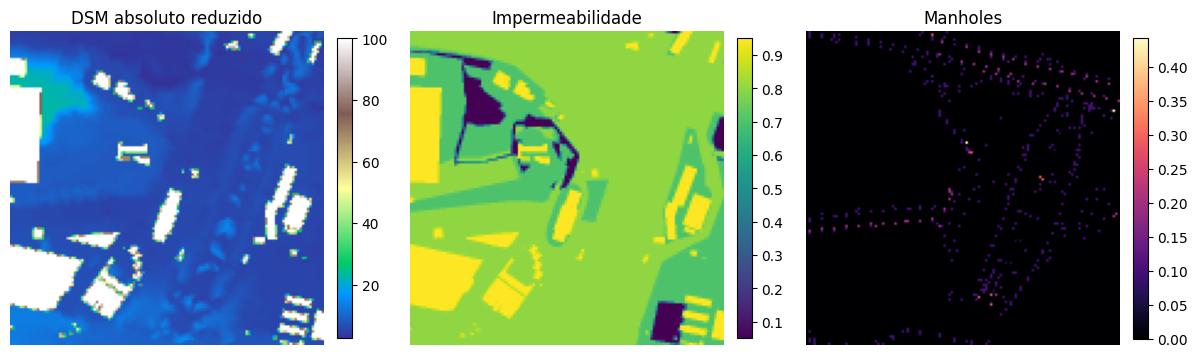

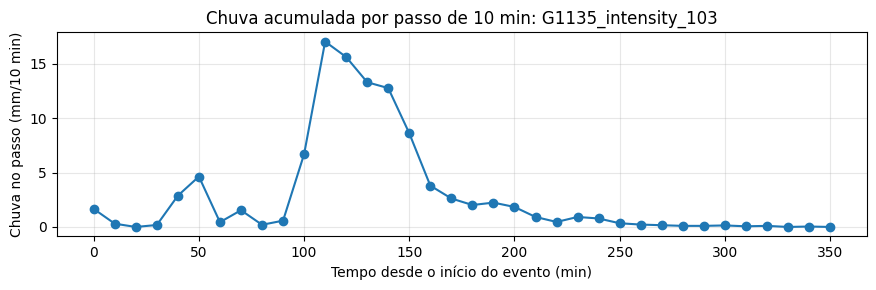

In [4]:
geodata = np.load(geodata_path)
figure_test_path = test_paths[TEST_EVENTS.index(TEST_EVENT_FOR_FIGURES)]
figure_test_sample = np.load(figure_test_path)

dem = geodata["dem"]
impervious = geodata["impervious"]
manhole = geodata["manhole"]
test_rainfall = figure_test_sample["rainfall"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
items = [
    (dem, "DSM absoluto reduzido", "terrain"),
    (impervious, "Impermeabilidade", "viridis"),
    (manhole, "Manholes", "magma"),
]
for ax, (data, title, cmap) in zip(axes, items):
    im = ax.imshow(data, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.savefig(OUTPUT_DIR / "geodados_location1.png", dpi=160)
plt.show()

plt.figure(figsize=(9, 3))
plt.plot(np.arange(TEMPORAL_STEPS) * 10, test_rainfall, marker="o", linewidth=1.5)
plt.title(f"Chuva acumulada por passo de 10 min: {TEST_EVENT_FOR_FIGURES}")
plt.xlabel("Tempo desde o início do evento (min)")
plt.ylabel("Chuva no passo (mm/10 min)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chuva_evento_teste.png", dpi=160)
plt.show()

## 4. Preparação dos tensores

O modelo recebe, a cada passo temporal:

- profundidade de inundação anterior;
- chuva do passo atual;
- chuva acumulada até o passo atual;
- três mapas estáticos: DSM, impermeabilidade e manholes.

A tarefa é prever a profundidade de inundação do próximo passo temporal.

In [5]:
train_samples = [np.load(path) for path in train_paths]
test_samples = [np.load(path) for path in test_paths]

flood_values = np.concatenate([sample["flood"].reshape(-1) for sample in train_samples])
rainfall_values = np.concatenate([sample["rainfall"].reshape(-1) for sample in train_samples])
cumulative_values = np.concatenate([np.cumsum(sample["rainfall"]).reshape(-1) for sample in train_samples])

FLOOD_SCALE = max(float(np.percentile(flood_values, 99.9)), 1e-6)
RAIN_SCALE = max(float(np.max(rainfall_values)), 1e-6)
CUM_RAIN_SCALE = max(float(np.max(cumulative_values)), 1e-6)

dem_norm = (dem - dem.min()) / max(float(dem.max() - dem.min()), 1e-6)
impervious_norm = np.clip(impervious, 0, 1)
manhole_norm = np.clip(manhole, 0, 1)
static_np = np.stack([dem_norm, impervious_norm, manhole_norm], axis=0).astype(np.float32)

print(f"Escala de inundação usada: {FLOOD_SCALE:.4f} m")
print(f"Escala de chuva por passo: {RAIN_SCALE:.4f} mm/10 min")
print(f"Escala de chuva acumulada: {CUM_RAIN_SCALE:.4f} mm")
print("Shape dos mapas estáticos:", static_np.shape)

Escala de inundação usada: 1.3005 m
Escala de chuva por passo: 26.5600 mm/10 min
Escala de chuva acumulada: 180.7050 mm
Shape dos mapas estáticos: (3, 128, 128)


In [6]:
def make_tensors(sample) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    flood = sample["flood"][:, 0].astype(np.float32)
    rainfall = sample["rainfall"].astype(np.float32)
    cumulative = np.cumsum(rainfall).astype(np.float32)

    prev_flood = flood[:-1] / FLOOD_SCALE
    target_flood = flood[1:] / FLOOD_SCALE
    rain_step = rainfall[1:] / RAIN_SCALE
    cum_rain = cumulative[1:] / CUM_RAIN_SCALE

    prev = torch.from_numpy(prev_flood[None]).to(DEVICE)
    target = torch.from_numpy(target_flood[None]).to(DEVICE)
    rain = torch.from_numpy(rain_step[None]).to(DEVICE)
    cum = torch.from_numpy(cum_rain[None]).to(DEVICE)
    static = torch.from_numpy(static_np[None]).to(DEVICE)
    return prev, rain, cum, static, target


train_tensors = [make_tensors(sample) for sample in train_samples]
test_tensors = [make_tensors(sample) for sample in test_samples]

train_prev = torch.cat([item[0] for item in train_tensors], dim=0)
train_rain = torch.cat([item[1] for item in train_tensors], dim=0)
train_cum = torch.cat([item[2] for item in train_tensors], dim=0)
train_static = torch.cat([item[3] for item in train_tensors], dim=0)
train_target = torch.cat([item[4] for item in train_tensors], dim=0)

test_prev = torch.cat([item[0] for item in test_tensors], dim=0)
test_rain = torch.cat([item[1] for item in test_tensors], dim=0)
test_cum = torch.cat([item[2] for item in test_tensors], dim=0)
test_static = torch.cat([item[3] for item in test_tensors], dim=0)
test_target = torch.cat([item[4] for item in test_tensors], dim=0)

print("Tensores de treino:")
print("prev:", tuple(train_prev.shape))
print("rain:", tuple(train_rain.shape))
print("static:", tuple(train_static.shape))
print("target:", tuple(train_target.shape))
print("Tensores de teste:")
print("prev:", tuple(test_prev.shape))
print("target:", tuple(test_target.shape))

Tensores de treino:
prev: (8, 35, 128, 128)
rain: (8, 35)
static: (8, 3, 128, 128)
target: (8, 35, 128, 128)
Tensores de teste:
prev: (4, 35, 128, 128)
target: (4, 35, 128, 128)


## 5. Modelos U-RNN simplificados

As arquiteturas abaixo são versões simplificadas da ideia central do U-RNN: combinar convoluções espaciais com estado recorrente convolucional.

São testadas duas versões:

- **Mini U-RNN**: encoder convolucional pequeno, ConvGRU e decoder residual.
- **U-RNN Lite U-like**: encoder-decoder em formato de U, com redução/aumento de escala e ConvGRU no gargalo. Esta versão é mais próxima da intuição da arquitetura original, mas ainda viável em CPU.

Como o nowcasting de curto prazo costuma ter forte continuidade temporal, os dois modelos preveem uma correção sobre o mapa de inundação anterior. Assim, a previsão inicial começa equivalente ao baseline de persistência e o treinamento aprende ajustes associados à chuva e aos mapas estáticos.

In [7]:
class ConvGRUCell(nn.Module):
    def __init__(self, input_channels: int, hidden_channels: int):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.gates = nn.Conv2d(
            input_channels + hidden_channels,
            2 * hidden_channels,
            kernel_size=3,
            padding=1,
        )
        self.candidate = nn.Conv2d(
            input_channels + hidden_channels,
            hidden_channels,
            kernel_size=3,
            padding=1,
        )

    def forward(self, x: torch.Tensor, h: torch.Tensor | None = None) -> torch.Tensor:
        if h is None:
            h = x.new_zeros(x.shape[0], self.hidden_channels, x.shape[2], x.shape[3])
        combined = torch.cat([x, h], dim=1)
        z, r = torch.sigmoid(self.gates(combined)).chunk(2, dim=1)
        candidate = torch.tanh(self.candidate(torch.cat([x, r * h], dim=1)))
        return (1 - z) * candidate + z * h


class MiniURNN(nn.Module):
    def __init__(self, hidden_channels: int = 8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(6, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.recurrent = ConvGRUCell(hidden_channels, hidden_channels)
        self.decoder = nn.Sequential(
            nn.Conv2d(hidden_channels, hidden_channels // 2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels // 2, 1, kernel_size=1),
        )
        final_conv = self.decoder[-1]
        nn.init.zeros_(final_conv.weight)
        nn.init.zeros_(final_conv.bias)

    def forward(
        self,
        previous_flood: torch.Tensor,
        rainfall: torch.Tensor,
        cumulative_rainfall: torch.Tensor,
        static_maps: torch.Tensor,
    ) -> torch.Tensor:
        batch, steps, height, width = previous_flood.shape
        h = None
        outputs = []
        for step in range(steps):
            rain_map = rainfall[:, step].view(batch, 1, 1, 1).expand(batch, 1, height, width)
            cum_map = cumulative_rainfall[:, step].view(batch, 1, 1, 1).expand(batch, 1, height, width)
            x = torch.cat(
                [
                    previous_flood[:, step : step + 1],
                    rain_map,
                    cum_map,
                    static_maps,
                ],
                dim=1,
            )
            encoded = self.encoder(x)
            h = self.recurrent(encoded, h)
            residual = 0.05 * torch.tanh(self.decoder(h))
            next_flood = torch.clamp(previous_flood[:, step : step + 1] + residual, 0.0, 1.0)
            outputs.append(next_flood)
        return torch.cat(outputs, dim=1)


class ConvBlock(nn.Module):
    def __init__(self, input_channels: int, output_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class URNNLiteULike(nn.Module):
    def __init__(self, base_channels: int = 8):
        super().__init__()
        self.encoder1 = ConvBlock(6, base_channels)
        self.encoder2 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            ConvBlock(base_channels * 2, base_channels * 2),
        )
        self.encoder3 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 3, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            ConvBlock(base_channels * 3, base_channels * 3),
        )
        self.recurrent = ConvGRUCell(base_channels * 3, base_channels * 3)
        self.up1 = nn.ConvTranspose2d(base_channels * 3, base_channels * 2, kernel_size=2, stride=2)
        self.decoder1 = ConvBlock(base_channels * 4, base_channels * 2)
        self.up2 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.decoder2 = ConvBlock(base_channels * 2, base_channels)
        self.output = nn.Conv2d(base_channels, 1, kernel_size=1)
        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(
        self,
        previous_flood: torch.Tensor,
        rainfall: torch.Tensor,
        cumulative_rainfall: torch.Tensor,
        static_maps: torch.Tensor,
    ) -> torch.Tensor:
        batch, steps, height, width = previous_flood.shape
        h = None
        outputs = []
        for step in range(steps):
            rain_map = rainfall[:, step].view(batch, 1, 1, 1).expand(batch, 1, height, width)
            cum_map = cumulative_rainfall[:, step].view(batch, 1, 1, 1).expand(batch, 1, height, width)
            x = torch.cat(
                [
                    previous_flood[:, step : step + 1],
                    rain_map,
                    cum_map,
                    static_maps,
                ],
                dim=1,
            )
            skip1 = self.encoder1(x)
            skip2 = self.encoder2(skip1)
            bottleneck = self.encoder3(skip2)
            h = self.recurrent(bottleneck, h)
            y = self.up1(h)
            y = self.decoder1(torch.cat([y, skip2], dim=1))
            y = self.up2(y)
            y = self.decoder2(torch.cat([y, skip1], dim=1))
            residual = 0.05 * torch.tanh(self.output(y))
            next_flood = torch.clamp(previous_flood[:, step : step + 1] + residual, 0.0, 1.0)
            outputs.append(next_flood)
        return torch.cat(outputs, dim=1)


models = {
    "Mini U-RNN": MiniURNN(hidden_channels=8).to(DEVICE),
    "U-RNN Lite U-like": URNNLiteULike(base_channels=8).to(DEVICE),
}

for model_name, model in models.items():
    total_params = sum(param.numel() for param in model.parameters())
    print(f"{model_name}: {total_params:,} parâmetros treináveis")

Mini U-RNN: 4,801 parâmetros treináveis
U-RNN Lite U-like: 62,673 parâmetros treináveis


## 6. Treinamento rápido em CPU

O treino abaixo é curto de propósito. Ele serve para demonstrar a integração dos modelos com os dados e gerar uma inferência verificável. O artigo original treina por muito mais tempo, com mais eventos e ambiente com GPU.

Mini U-RNN | época 01/20 - perda ponderada: 0.000682


Mini U-RNN | época 05/20 - perda ponderada: 0.000681


Mini U-RNN | época 10/20 - perda ponderada: 0.000680


Mini U-RNN | época 15/20 - perda ponderada: 0.000679


Mini U-RNN | época 20/20 - perda ponderada: 0.000678
Mini U-RNN | tempo de treinamento: 54.6 s


U-RNN Lite U-like | época 01/20 - perda ponderada: 0.000682


U-RNN Lite U-like | época 05/20 - perda ponderada: 0.000681


U-RNN Lite U-like | época 10/20 - perda ponderada: 0.000680


U-RNN Lite U-like | época 15/20 - perda ponderada: 0.000678


U-RNN Lite U-like | época 20/20 - perda ponderada: 0.000677
U-RNN Lite U-like | tempo de treinamento: 71.5 s


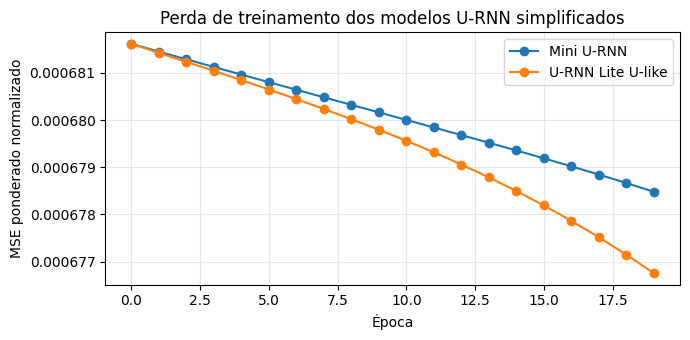

In [8]:
def train_model(model: nn.Module, model_name: str, epochs: int = 20) -> list[float]:
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
    history = []
    start = time.time()
    model.train()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad(set_to_none=True)
        prediction = model(train_prev, train_rain, train_cum, train_static)
        wet_weight = 1.0 + 4.0 * (train_target > (0.01 / FLOOD_SCALE)).float()
        loss = ((prediction - train_target) ** 2 * wet_weight).mean()
        loss.backward()
        optimizer.step()
        history.append(float(loss.detach().cpu()))
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(f"{model_name} | época {epoch:02d}/{epochs} - perda ponderada: {history[-1]:.6f}")
    print(f"{model_name} | tempo de treinamento: {time.time() - start:.1f} s")
    return history


histories = {}
for model_name, model in models.items():
    histories[model_name] = train_model(model, model_name, epochs=20)

plt.figure(figsize=(7, 3.5))
for model_name, history in histories.items():
    plt.plot(history, marker="o", label=model_name)
plt.title("Perda de treinamento dos modelos U-RNN simplificados")
plt.xlabel("Época")
plt.ylabel("MSE ponderado normalizado")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "perda_treinamento.png", dpi=160)
plt.show()

## 7. Inferência e métricas

A inferência é feita em quatro eventos de teste separados. Também calculamos um baseline de persistência, que prevê que o próximo mapa será igual ao mapa imediatamente anterior.

In [9]:
def to_numpy_meters(tensor: torch.Tensor) -> np.ndarray:
    return (tensor.detach().cpu().numpy() * FLOOD_SCALE).astype(np.float32)


predictions_m = {}
with torch.no_grad():
    for model_name, model in models.items():
        model.eval()
        pred_norm = model(test_prev, test_rain, test_cum, test_static)
        predictions_m[model_name] = to_numpy_meters(pred_norm)

mini_prediction_m = predictions_m["Mini U-RNN"]
u_like_prediction_m = predictions_m["U-RNN Lite U-like"]
reference_m = to_numpy_meters(test_target)
persistence_m = to_numpy_meters(test_prev)


def fit_residual_regression(train_samples, stride: int = 8) -> np.ndarray:
    x_parts = []
    y_parts = []
    for sample in train_samples:
        flood = sample["flood"][:, 0].astype(np.float32)
        rainfall = sample["rainfall"].astype(np.float32)
        cumulative = np.cumsum(rainfall).astype(np.float32)

        previous = flood[:-1, ::stride, ::stride]
        residual = flood[1:, ::stride, ::stride] - previous
        rain_feature = np.broadcast_to(rainfall[1:, None, None], previous.shape)
        cumulative_feature = np.broadcast_to(cumulative[1:, None, None], previous.shape)

        x_parts.append(
            np.stack(
                [
                    previous.reshape(-1),
                    rain_feature.reshape(-1),
                    cumulative_feature.reshape(-1),
                    np.ones(previous.size, dtype=np.float32),
                ],
                axis=1,
            )
        )
        y_parts.append(residual.reshape(-1))

    x_train = np.concatenate(x_parts, axis=0)
    y_train = np.concatenate(y_parts, axis=0)
    coefficients, *_ = np.linalg.lstsq(x_train, y_train, rcond=None)
    return coefficients.astype(np.float32)


residual_coefficients = fit_residual_regression(train_samples)
residual_regression_items = []
for sample in test_samples:
    test_flood = sample["flood"][:, 0].astype(np.float32)
    test_rainfall = sample["rainfall"].astype(np.float32)
    test_cumulative = np.cumsum(test_rainfall).astype(np.float32)
    residual_prediction = (
        residual_coefficients[0] * test_flood[:-1]
        + residual_coefficients[1] * test_rainfall[1:, None, None]
        + residual_coefficients[2] * test_cumulative[1:, None, None]
        + residual_coefficients[3]
    )
    residual_regression_items.append(np.clip(test_flood[:-1] + residual_prediction, 0, None))
residual_regression_m = np.stack(residual_regression_items, axis=0)

def compute_metrics(pred: np.ndarray, ref: np.ndarray) -> dict[str, float]:
    y_pred = pred.reshape(-1)
    y_true = ref.reshape(-1)
    mae = float(np.mean(np.abs(y_pred - y_true)))
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    r2 = float(r2_score(y_true, y_pred))
    wet_ref = y_true > 0.01
    if wet_ref.any():
        wet_mae = float(np.mean(np.abs(y_pred[wet_ref] - y_true[wet_ref])))
    else:
        wet_mae = float("nan")
    return {
        "MAE_m": mae,
        "RMSE_m": rmse,
        "R2": r2,
        "MAE_apenas_celulas_molhadas_m": wet_mae,
    }


model_predictions = {
    "Persistência": persistence_m,
    "Regressão residual": residual_regression_m,
    "Mini U-RNN": mini_prediction_m,
    "U-RNN Lite U-like": u_like_prediction_m,
}

per_event_rows = []
for model_name, pred in model_predictions.items():
    for event_index, event_name in enumerate(TEST_EVENTS):
        per_event_rows.append(
            {
                "modelo": model_name,
                "evento": event_name,
                **compute_metrics(pred[event_index], reference_m[event_index]),
            }
        )

metrics_per_event = pd.DataFrame(per_event_rows)
summary_rows = []
for model_name, pred in model_predictions.items():
    global_metrics = compute_metrics(pred, reference_m)
    event_metrics = metrics_per_event[metrics_per_event["modelo"] == model_name]
    summary_rows.append(
        {
            "modelo": model_name,
            "eventos_teste": len(TEST_EVENTS),
            **global_metrics,
            "MAE_m_media_por_evento": float(event_metrics["MAE_m"].mean()),
            "MAE_m_desvio_por_evento": float(event_metrics["MAE_m"].std(ddof=0)),
            "RMSE_m_media_por_evento": float(event_metrics["RMSE_m"].mean()),
            "RMSE_m_desvio_por_evento": float(event_metrics["RMSE_m"].std(ddof=0)),
            "R2_media_por_evento": float(event_metrics["R2"].mean()),
            "R2_desvio_por_evento": float(event_metrics["R2"].std(ddof=0)),
        }
    )

metrics = pd.DataFrame(summary_rows)
metrics_path = OUTPUT_DIR / "metricas.csv"
metrics_per_event_path = OUTPUT_DIR / "metricas_por_evento.csv"
metrics.to_csv(metrics_path, index=False)
metrics_per_event.to_csv(metrics_per_event_path, index=False)
print("Métricas agregadas:")
display(metrics)
print("Métricas por evento:")
display(metrics_per_event)
print("Coeficientes da regressão residual [inundação anterior, chuva, chuva acumulada, intercepto]:")
print(residual_coefficients)
print(f"Métricas salvas em: {metrics_path}")
print(f"Métricas por evento salvas em: {metrics_per_event_path}")

Métricas agregadas:


,modelo,eventos_teste,MAE_m,RMSE_m,R2,MAE_apenas_celulas_molhadas_m,MAE_m_media_por_evento,MAE_m_desvio_por_evento,RMSE_m_media_por_evento,RMSE_m_desvio_por_evento,R2_media_por_evento,R2_desvio_por_evento
0,Persistência,4,0.002105,0.012997,0.982369,0.016777,0.002105,0.000105,0.012985,0.000561,0.980567,0.006462
1,Regressão residual,4,0.003102,0.012716,0.983124,0.015976,0.003102,0.000158,0.012705,0.000519,0.981372,0.006246
2,Mini U-RNN,4,0.002978,0.013491,0.981004,0.017650,0.002978,0.000123,0.013470,0.000748,0.979282,0.006299
3,U-RNN Lite U-like,4,0.003343,0.013489,0.981009,0.017760,0.003343,0.000124,0.013468,0.000744,0.979292,0.006270


Métricas por evento:


,modelo,evento,MAE_m,RMSE_m,R2,MAE_apenas_celulas_molhadas_m
0,Persistência,G1135_intensity_103,0.002218,0.013116,0.985100,0.016258
1,Persistência,G1135_intensity_161,0.001935,0.012075,0.981889,0.016854
2,Persistência,G1166_intensity_246,0.002155,0.013137,0.969653,0.024725
3,Persistência,G3501_intensity_151,0.002111,0.013611,0.985627,0.012954
4,Regressão residual,G1135_intensity_103,0.003214,0.012742,0.985938,0.015556
5,Regressão residual,G1135_intensity_161,0.002834,0.011887,0.982450,0.016259
6,Regressão residual,G1166_intensity_246,0.003222,0.012872,0.970865,0.023237
7,Regressão residual,G3501_intensity_151,0.003139,0.013321,0.986235,0.012289
8,Mini U-RNN,G1135_intensity_103,0.003138,0.013999,0.983025,0.017477
9,Mini U-RNN,G1135_intensity_161,0.002793,0.012289,0.981243,0.017578


Coeficientes da regressão residual [inundação anterior, chuva, chuva acumulada, intercepto]:
[ 4.0076333e-03  6.3301058e-04 -2.7529422e-06 -1.0192735e-03]
Métricas salvas em: outputs\metricas.csv
Métricas por evento salvas em: outputs\metricas_por_evento.csv


### Interpretação das métricas

A persistência é um baseline muito forte neste experimento porque a previsão é feita passo a passo em intervalos de 10 minutos. Em eventos de inundação, o mapa do próximo instante tende a ser muito parecido com o mapa imediatamente anterior.

As métricas agora são calculadas em quatro eventos de teste, com uma tabela agregada e outra por evento. Isso torna a avaliação mais robusta do que uma única inferência, embora ainda seja um experimento reduzido em relação ao artigo.

A regressão residual foi incluída como comparação adicional simples. Ela estima a variação esperada entre dois passos usando apenas os eventos de treino. O Mini U-RNN e o U-RNN Lite U-like mantêm a parte neural recorrente/convolucional inspirada no U-RNN, mas foram treinados em CPU, com dados reduzidos e por um número de épocas ainda modesto.

## 8. Evidência visual do nowcasting

A figura abaixo segue a mesma lógica de visualização do projeto oficial: referência, previsão e erro absoluto em diferentes instantes do evento.

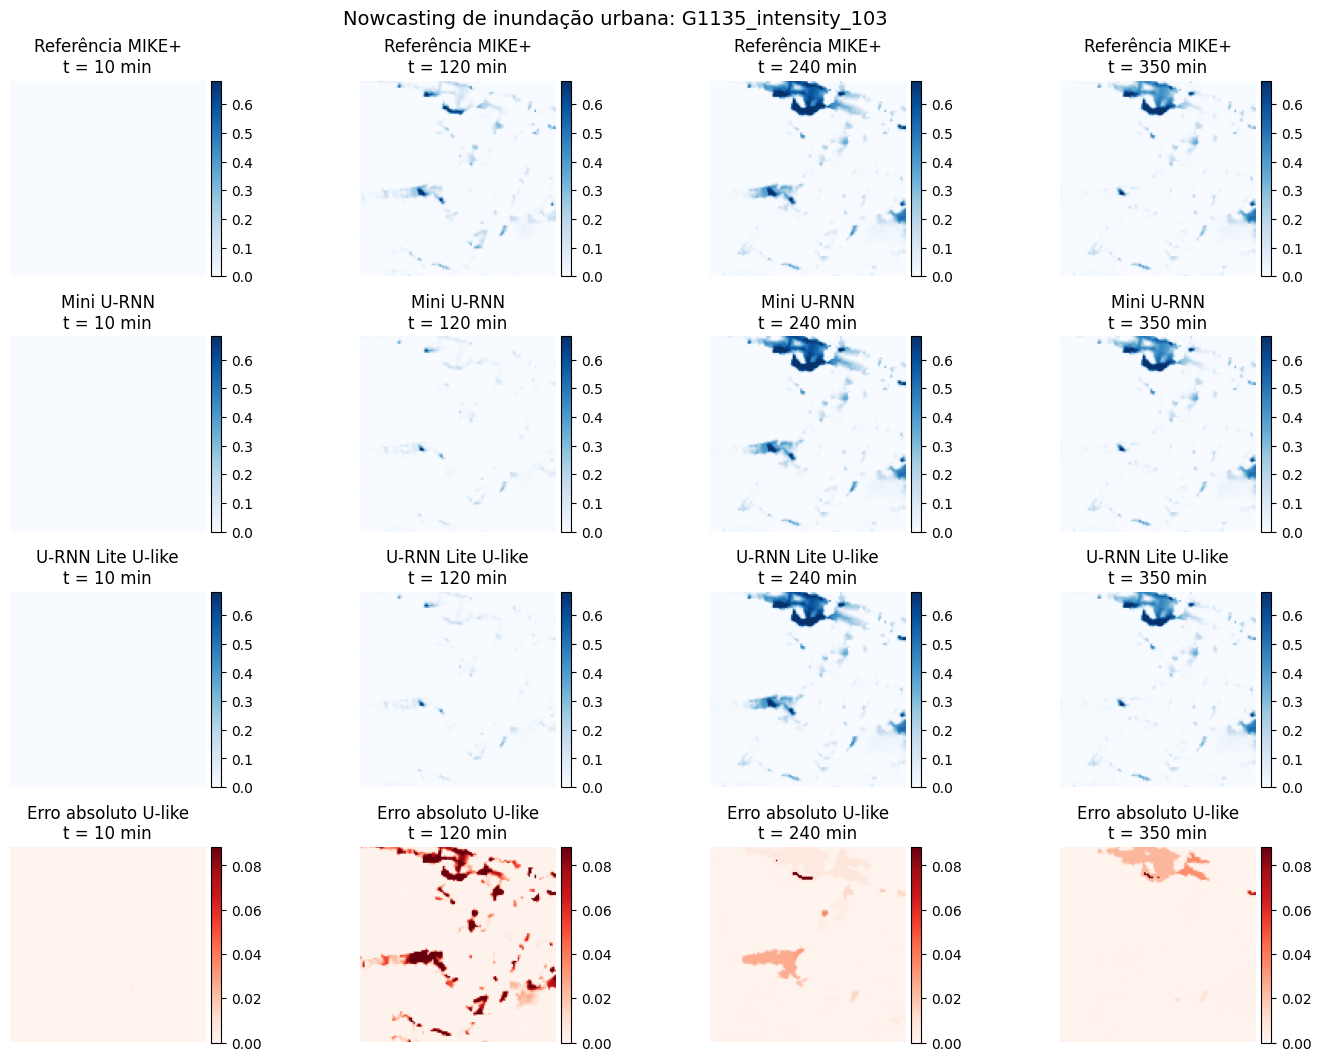

Figura salva em: outputs\comparacao_nowcasting.png


In [10]:
time_indices = [0, 11, 23, 34]
figure_event_index = TEST_EVENTS.index(TEST_EVENT_FOR_FIGURES)
fig, axes = plt.subplots(4, len(time_indices), figsize=(14, 10.5), constrained_layout=True)

reference_for_figure = reference_m[figure_event_index]
mini_for_figure = mini_prediction_m[figure_event_index]
u_like_for_figure = u_like_prediction_m[figure_event_index]

vmax = max(float(np.percentile(reference_for_figure, 99.5)), 0.1)
err = np.abs(u_like_for_figure - reference_for_figure)
err_vmax = max(float(np.percentile(err, 99.5)), 0.05)

row_data = [
    (reference_for_figure, "Referência MIKE+", "Blues", 0, vmax),
    (mini_for_figure, "Mini U-RNN", "Blues", 0, vmax),
    (u_like_for_figure, "U-RNN Lite U-like", "Blues", 0, vmax),
    (err, "Erro absoluto U-like", "Reds", 0, err_vmax),
]

for row, (data, row_title, cmap, vmin, vmax_row) in enumerate(row_data):
    for col, idx in enumerate(time_indices):
        ax = axes[row, col]
        im = ax.imshow(data[idx], cmap=cmap, vmin=vmin, vmax=vmax_row)
        minutes = (idx + 1) * 10
        ax.set_title(f"{row_title}\nt = {minutes} min")
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

fig.suptitle(f"Nowcasting de inundação urbana: {TEST_EVENT_FOR_FIGURES}", fontsize=14)
comparison_path = OUTPUT_DIR / "comparacao_nowcasting.png"
fig.savefig(comparison_path, dpi=170)
plt.show()

print(f"Figura salva em: {comparison_path}")

## 9. Aderência aos requisitos da atividade

Esta entrega contempla os pontos solicitados:

- usa os materiais do U-RNN como referência metodológica;
- utiliza o dataset suplementar `urbanflood24.zip` como origem metodológica dos dados;
- inclui no GitHub o subconjunto processado leve usado pelo notebook;
- implementa uma solução Python em notebook;
- executa uma demonstração simplificada de nowcasting com 8 eventos de treino e 4 eventos de teste;
- gera mapas, gráficos, métricas e arquivos de evidência;
- documenta dependências, instruções, decisões técnicas e limitações;
- mantém o experimento verificável em CPU, sem descompactar o dataset completo.

## 10. Conclusão

O notebook demonstra um fluxo completo e verificável para nowcasting de inundações urbanas:

- inspeção e leitura seletiva do dataset;
- redução espaço-temporal compatível com execução em CPU;
- uso de chuva, mapas urbanos estáticos e histórico de inundação;
- implementação de dois modelos recorrentes convolucionais inspirados no U-RNN;
- comparação com baseline, métricas e visualizações.

A principal limitação é que o treinamento foi intencionalmente curto e usa poucos eventos, portanto os resultados não devem ser comparados diretamente com os do artigo. Ainda assim, a solução é funcional, reprodutível e tecnicamente alinhada ao problema proposto.

In [11]:
summary = {
    "zip_original_presente": ZIP_PATH.exists(),
    "usa_subconjunto_processado": USE_PREPROCESSED,
    "location": LOCATION,
    "train_events": TRAIN_EVENTS,
    "test_events": TEST_EVENTS,
    "figure_event": TEST_EVENT_FOR_FIGURES,
    "processed_shape": list(figure_test_sample["flood"].shape),
    "models": list(models.keys()),
    "outputs": sorted(path.name for path in OUTPUT_DIR.glob("*")),
}
print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "zip_original_presente": true,
  "usa_subconjunto_processado": true,
  "location": "location1",
  "train_events": [
    "G1135_intensity_117",
    "G1135_intensity_155",
    "G1135_intensity_156",
    "G1135_intensity_163",
    "G1162_intensity_170",
    "G1166_intensity_120",
    "G3501_intensity_105",
    "G3555_intensity_284"
  ],
  "test_events": [
    "G1135_intensity_103",
    "G1135_intensity_161",
    "G1166_intensity_246",
    "G3501_intensity_151"
  ],
  "figure_event": "G1135_intensity_103",
  "processed_shape": [
    36,
    1,
    128,
    128
  ],
  "models": [
    "Mini U-RNN",
    "U-RNN Lite U-like"
  ],
  "outputs": [
    "chuva_evento_teste.png",
    "comparacao_nowcasting.png",
    "geodados_location1.png",
    "metricas.csv",
    "metricas_por_evento.csv",
    "perda_treinamento.png"
  ]
}
